In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("HR_data_2.csv", index_col=0)
print("Shape:", df.shape)
print("\nColumn dtypes summary:")
print(df.dtypes.value_counts())
print("\nFirst few columns:")
print(df.columns.tolist()[:10])
print("\nLast 20 columns (metadata + emotions):")
print(df.columns.tolist()[-20:])

Shape: (312, 70)

Column dtypes summary:
float64    62
object      5
int64       3
Name: count, dtype: int64

First few columns:
['HR_TD_Mean', 'HR_TD_Median', 'HR_TD_std', 'HR_TD_Min', 'HR_TD_Max', 'HR_TD_AUC', 'HR_TD_Kurtosis', 'HR_TD_Skew', 'HR_TD_Slope_min', 'HR_TD_Slope_max']

Last 20 columns (metadata + emotions):
['EDA_TD_P_ReT', 'Round', 'Phase', 'Individual', 'Puzzler', 'original_ID', 'raw_data_path', 'Team_ID', 'Frustrated', 'Cohort', 'upset', 'hostile', 'alert', 'ashamed', 'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']


In [3]:
# How many rows per individual?
print("Rows per individual:")
print(df['Individual'].value_counts().sort_index())

# Phase and Round distribution
print("\nPhase counts:")
print(df['Phase'].value_counts())
print("\nRound counts:")
print(df['Round'].value_counts())

# Cohort distribution
print("\nCohort counts:")
print(df['Cohort'].value_counts())

Rows per individual:
Individual
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12
11    12
12    12
13    12
14    12
15    12
16    12
17    12
18    12
19    12
20    12
21    12
22    12
23    12
24    12
25    12
26    12
Name: count, dtype: int64

Phase counts:
Phase
phase3    104
phase2    104
phase1    104
Name: count, dtype: int64

Round counts:
Round
round_3    78
round_2    78
round_4    78
round_1    78
Name: count, dtype: int64

Cohort counts:
Cohort
D1_1    96
D1_2    72
D1_4    48
D1_3    48
D1_6    24
D1_5    24
Name: count, dtype: int64


In [4]:
# Total NaN count per column, only showing columns with any missing
missing = df.isna().sum()
missing_cols = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing_cols)
print(f"\nTotal cells missing: {df.isna().sum().sum()}")
print(f"Rows with at least one NaN: {df.isna().any(axis=1).sum()} / {len(df)}")

Columns with missing values:
inspired        2
determined      2
EDA_TD_P_RT     1
EDA_TD_P_ReT    1
attentive       1
afraid          1
active          1
dtype: int64

Total cells missing: 9
Rows with at least one NaN: 5 / 312


In [5]:
# Where is the missingness? By phase and by individual.
if missing_cols.any():
    nan_rows = df[df.isna().any(axis=1)]
    print("\nMissing rows by phase:")
    print(nan_rows['Phase'].value_counts())
    print("\nMissing rows by individual:")
    print(nan_rows['Individual'].value_counts().sort_index())


Missing rows by phase:
Phase
phase1    4
phase3    1
Name: count, dtype: int64

Missing rows by individual:
Individual
9     1
11    3
23    1
Name: count, dtype: int64


In [6]:
# Look at the actual rows with missing EDA peak features
eda_nan = df[df['EDA_TD_P_RT'].isna() | df['EDA_TD_P_ReT'].isna()]
print(eda_nan[['Individual', 'Round', 'Phase', 'EDA_TD_P_Peaks', 'EDA_TD_P_RT', 'EDA_TD_P_ReT']])

     Individual    Round   Phase  EDA_TD_P_Peaks  EDA_TD_P_RT  EDA_TD_P_ReT
272          23  round_4  phase1               1          NaN           NaN


In [7]:
# Identify the biosignal feature columns (everything before 'Round')
metadata_cols = ['Round', 'Phase', 'Individual', 'Puzzler', 'original_ID', 
                 'raw_data_path', 'Team_ID', 'Cohort']
emotion_cols = ['Frustrated', 'upset', 'hostile', 'alert', 'ashamed', 
                'inspired', 'nervous', 'attentive', 'afraid', 'active', 'determined']
feature_cols = [c for c in df.columns if c not in metadata_cols + emotion_cols]
print(f"Number of biosignal feature columns: {len(feature_cols)}")

# Summary statistics
summary = df[feature_cols].describe().T
print("\nFeature summary (range of means, stds):")
print(f"  Min mean: {summary['mean'].min():.4g}, Max mean: {summary['mean'].max():.4g}")
print(f"  Min std:  {summary['std'].min():.4g}, Max std:  {summary['std'].max():.4g}")

# Show the 5 features with biggest and smallest scales
print("\nLargest-scale features (by mean magnitude):")
print(summary['mean'].abs().sort_values(ascending=False).head(5))
print("\nSmallest-scale features:")
print(summary['mean'].abs().sort_values().head(5))

Number of biosignal feature columns: 51

Feature summary (range of means, stds):
  Min mean: -0.568, Max mean: 4.088e+04
  Min std:  0.0003036, Max std:  6578

Largest-scale features (by mean magnitude):
TEMP_TD_AUC     40875.088077
HR_TD_AUC       24307.558590
EDA_TD_T_AUC     4644.033566
EDA_TD_P_AUC      516.088267
HR_TD_Max          92.451122
Name: mean, dtype: float64

Smallest-scale features:
TEMP_TD_Slope_mean     0.000031
TEMP_TD_Slope          0.000033
EDA_TD_T_Slope         0.000144
EDA_TD_T_Slope_mean    0.000210
EDA_TD_P_Slope         0.000334
Name: mean, dtype: float64


In [8]:
from scipy import stats

# Compute skewness and excess kurtosis for each feature (ignore NaNs)
shape = pd.DataFrame({
    'skew': df[feature_cols].apply(lambda x: stats.skew(x.dropna())),
    'kurt': df[feature_cols].apply(lambda x: stats.kurtosis(x.dropna())),  # excess kurtosis
})

print("Most skewed features (positive = right-tailed):")
print(shape.reindex(shape['skew'].abs().sort_values(ascending=False).index).head(8))

print("\nFeatures with reasonably normal shape (|skew| < 0.5, |kurt| < 1):")
tame = shape[(shape['skew'].abs() < 0.5) & (shape['kurt'].abs() < 1)]
print(f"{len(tame)} out of {len(feature_cols)} features")

Most skewed features (positive = right-tailed):
                         skew        kurt
EDA_TD_P_Min        -8.764989  101.290520
HR_TD_Slope_max      6.837194   71.520114
EDA_TD_T_Kurtosis    5.769679   45.633815
EDA_TD_P_Median      4.739589   23.697167
EDA_TD_P_Mean        4.134182   18.333558
EDA_TD_P_AUC         4.083099   17.902612
EDA_TD_P_Slope_mean  3.879939   16.971334
EDA_TD_T_Min         3.603981   19.978788

Features with reasonably normal shape (|skew| < 0.5, |kurt| < 1):
7 out of 51 features


# Phase 1 EDA — Summary of Findings

## Dataset structure

- **312 rows × 70 columns**, where each row corresponds to one (Individual, Round, Phase) recording.
- **26 individuals**, each with exactly 12 rows (4 rounds × 3 phases). Perfectly balanced — no missing recordings.
- Cohort distribution matches the data description: D1_1 (8 participants), D1_2 (6), D1_3/D1_4 (4 each), D1_5/D1_6 (2 each).
- **51 biosignal features** (HR, TEMP, EDA tonic, EDA phasic) + 11 self-reported emotion ratings + 8 metadata columns.

> **Implication for validation:** rows are *not* independent — repeated measures from the same individual are nested within rounds and phases. Random train/test splits would leak subject-specific baselines; a subject-level (e.g., Leave-One-Subject-Out) split is required for valid generalization estimates.

## Missing values

- Only **9 missing cells** out of ~21,840 (5 rows affected).
- **7 cells** are missing emotion ratings (PANAS items: `inspired`, `determined`, `attentive`, `afraid`, `active`) — benign, attributable to participants skipping survey items. Concentrated in 3 individuals during rest phases.
- **2 cells** are missing EDA-phasic timing features (`EDA_TD_P_RT`, `EDA_TD_P_ReT`) for one row (Individual 23, round 4, phase 1). The `EDA_TD_P_Peaks` count for that row is 1, so the missingness reflects an edge-case peak that could not be fully characterized within the recording window (likely truncated), not absence of peaks.

> **Handling decision (to be finalized):** drop the single problematic biosignal row or median-impute. Emotion-rating NaNs only matter if these columns are used downstream; otherwise, ignore.

## Feature scales

- Feature means span roughly **9 orders of magnitude**: from ~3×10⁻⁵ (`TEMP_TD_Slope_mean`) to ~4×10⁴ (`TEMP_TD_AUC`).
- Standard deviations show similar spread (~3×10⁻⁴ up to ~6.6×10³).
- AUC features are large because they integrate signal values over many time samples; slope features are tiny because the underlying signals change slowly.

> **Implication:** standardization (z-scoring) is mandatory before any distance-based or variance-based method (PCA, K-means, SVM, t-SNE, UMAP). Without it, AUC features would dominate every distance and every principal component for purely numerical reasons unrelated to information content.

## Distribution shape

- Only **7 of 51 features** are approximately bell-shaped (|skew| < 0.5 and |excess kurtosis| < 1).
- The remaining 44 are skewed, heavy-tailed, or both.
- Most extreme cases are EDA-phasic features: `EDA_TD_P_Min` has skewness ≈ −8.8 and excess kurtosis ≈ 101.
- The heavy tails are *physiologically meaningful*, not artifacts — phasic EDA is by nature near zero with occasional sharp peaks, so its summary statistics inherit that spiky distribution.

> **Implication:** linear methods that assume approximate Gaussianity (PCA, LDA) will be partially driven by outliers. Options to address this: (1) accept and document the limitation; (2) apply log or signed-log transforms to AUC/EDA features; (3) use robust alternatives (rank-based PCA, median/IQR scaling, Isolation Forest). Decision to be made when method is selected.

## Per-subject baseline variation

- The case description explicitly warns that biosignals are "highly dependent on individual baselines" — confirmed conceptually by the dataset structure (HR, EDA, and TEMP all vary substantially between individuals at rest).
- Three plausible standardization strategies, each with different interpretive consequences:
  - **Global standardization** preserves between-subject differences (could detect "high-stress individuals" overall).
  - **Per-subject standardization** removes individual baselines and focuses on within-person variation.
  - **Per-subject baseline subtraction** (subtract individual's resting-phase mean) explicitly frames the question as "deviation from rest."

> **Decision pending** — depends on the chosen track and research question.

## Open question (next step)

Does the experimental phase produce visible separation in the biosignal features at all? Boxplots of physiologically interpretable features (`HR_TD_Mean`, `EDA_TD_T_Mean`, `TEMP_TD_Mean`, `EDA_TD_P_Peaks`) across phase1 / phase2 / phase3 will give a first answer. If between-phase differences are small relative to between-individual variation, the entire project will need to be framed around weak-signal methodology and honest limitation reporting (which the rubric explicitly rewards).

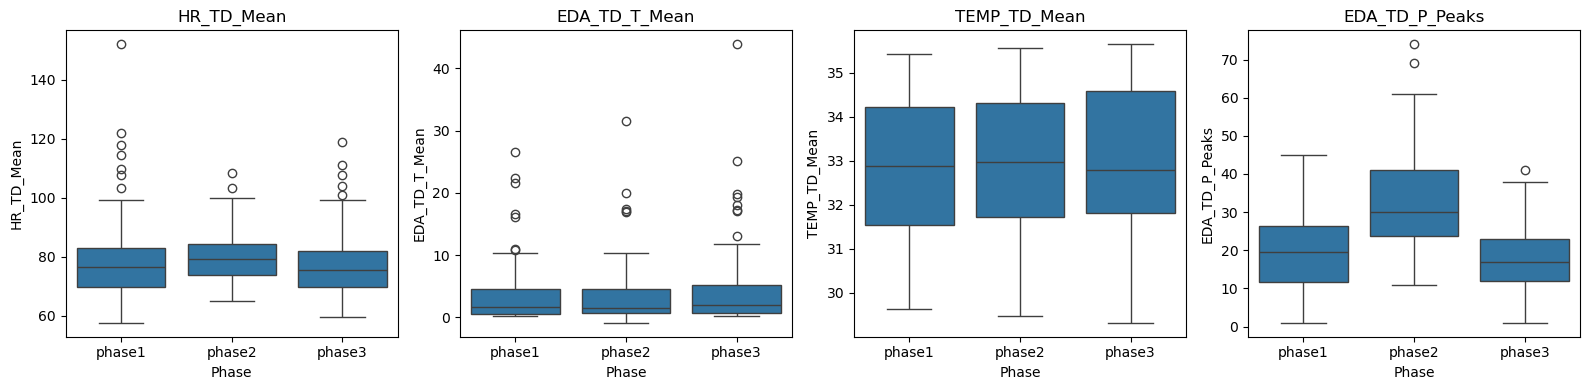


Mean per phase:
Phase              phase1     phase2     phase3
HR_TD_Mean      78.546709  79.821439  77.281774
EDA_TD_T_Mean    3.542304   3.390180   4.362656
TEMP_TD_Mean    32.850516  32.953082  32.912368
EDA_TD_P_Peaks  19.846154  32.384615  18.326923


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick a few physiologically interpretable features
features_to_check = ['HR_TD_Mean', 'EDA_TD_T_Mean', 'TEMP_TD_Mean', 'EDA_TD_P_Peaks']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, feat in zip(axes, features_to_check):
    sns.boxplot(data=df, x='Phase', y=feat, ax=ax,
                order=['phase1', 'phase2', 'phase3'])
    ax.set_title(feat)
plt.tight_layout()
plt.show()

# And group means
print("\nMean per phase:")
print(df.groupby('Phase')[features_to_check].mean().T)